In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt

TXT_DIR = Path("../tools/in")
JSON_DIR = Path("../pahcer/json")
json_path1 = JSON_DIR / "sub05.json"
json_path2 = JSON_DIR / "ok.json"


def load_json(json_path):
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)
    
    scores = []
    turns = []
    paint_nums = []
    for item in data["cases"]:
        scores.append(item["score"])
        txt_file = TXT_DIR / f'{item["seed"]:04d}.txt'
        with open(txt_file, "r", encoding="utf-8") as f:
            N, K, H, T, D = map(int, f.readline().strip().split())
            turns.append(T)
            paint_nums.append(K)
    
    return scores, turns, paint_nums

scores1, turns1, paint_nums1 = load_json(json_path1)
scores2, turns2, paint_nums2 = load_json(json_path2)

In [3]:
import math

log_101_scores1 = [math.log(s, 1.01) for s in scores1]
log_101_scores2 = [math.log(s, 1.01) for s in scores2]
log10_scores1 = [math.log10(s) for s in scores1]
log10_scores2 = [math.log10(s) for s in scores2]

sum101_scores1 = sum(log_101_scores1)
sum101_scores2 = sum(log_101_scores2)
sum10_scores1 = sum(log10_scores1)
sum10_scores2 = sum(log10_scores2)


In [10]:
sum101_scores2 / 100

1213.2422658751152

In [9]:
sum101_scores1 / 100

1233.5242121851647

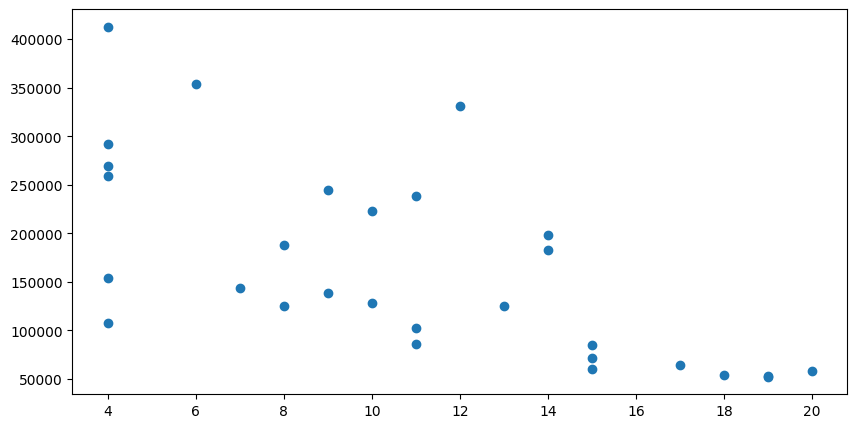

In [22]:
import numpy as np

scores_np = np.array(scores)
scores2_np = np.array(scores2)
turns_np = np.array(turns)
paint_nums_np = np.array(paint_nums)

flag =turns_np > 25000

fig = plt.figure(figsize=(10, 5))
plt.scatter(paint_nums_np[flag], scores_np[flag])
plt.show()


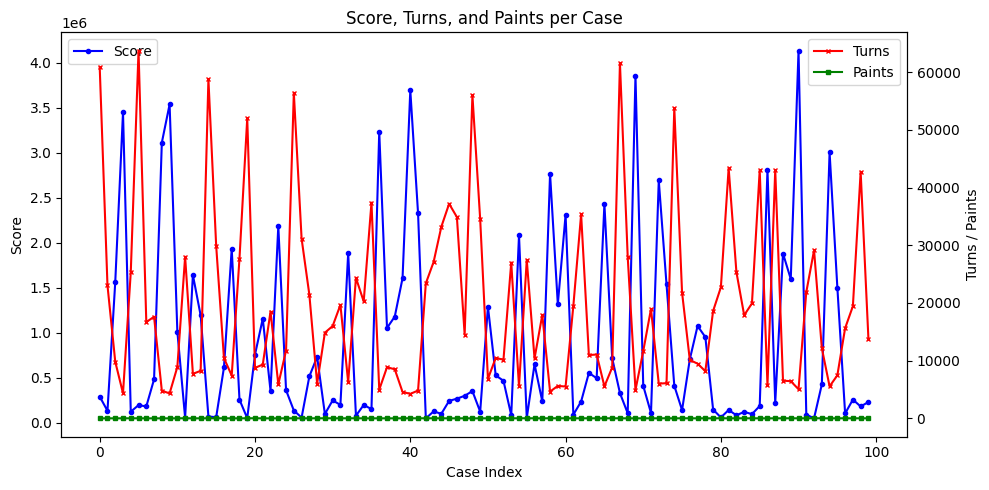

In [23]:
# score1に対して、ターンとスコアの2軸
fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(111)
ax2 = ax1.twinx()
x = range(len(scores))
ax1.plot(x, scores, label="Score", color="blue", marker='o', markersize=3)
ax2.plot(x, turns, label="Turns", color="red", marker='x', markersize=3)
ax2.plot(x, paint_nums, label="Paints", color="green", marker='s', markersize=3)
ax1.set_xlabel("Case Index")
ax1.set_ylabel("Score")
ax2.set_ylabel("Turns / Paints")
ax1.set_title("Score, Turns, and Paints per Case")
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.tight_layout()
plt.show()


In [24]:
pred_scores = []
for score1, score2 in zip(scores, scores2):
    pred_score = score2 / score1 * 1e9
    pred_scores.append(pred_score)

In [25]:
sum(pred_scores) / 2

60108449554.01743

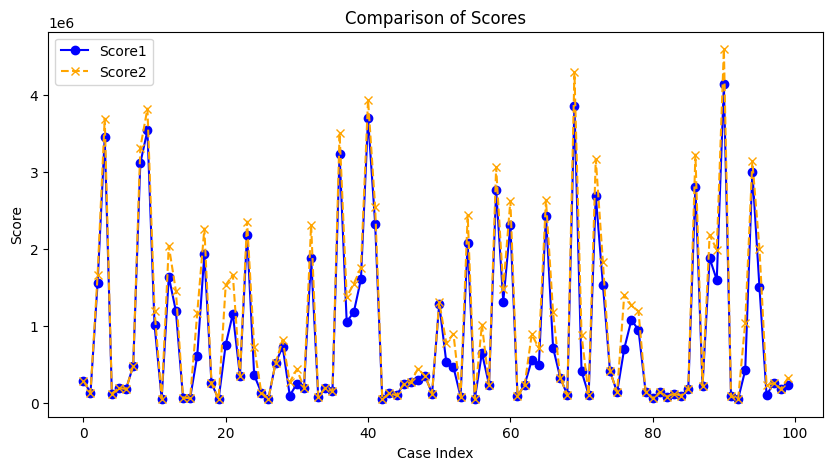

In [26]:
plt.figure(figsize=(10, 5))
plt.plot(scores, label="Score1", marker='o', linestyle='-', color='blue')
plt.plot(scores2, label="Score2", marker='x', linestyle='--', color='orange')
plt.title("Comparison of Scores")
plt.xlabel("Case Index")
plt.ylabel("Score")
plt.legend()
plt.show()